# RuReviews — тональность отзывов: TF-IDF+LogReg baseline, fine-tuned BERT

Задача: классификация тональности отзыва
на женскую одежду/аксессуары: **negative / neautral / positive**


**Дообучение — full fine-tuning**

**Baseline — TF-IDF + логистическая регрессия**


## 1. Импорты и настройки

In [2]:
!pip install transformers --quiet

In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [4]:
RANDOM_STATE = 20
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", DEVICE)

CHECKPOINT = "DeepPavlov/rubert-base-cased"
MAX_LENGTH = 128
BATCH_SIZE = 32
EPOCHS = 6
LR = 2e-5
EARLY_STOP_PATIENCE = 2


Устройство: cuda


## 2. Загрузка данных

In [5]:
DATA_URL = "https://raw.githubusercontent.com/sismetanin/rureviews/master/women-clothing-accessories.3-class.balanced.csv"

In [6]:
df = pd.read_csv(DATA_URL, sep="\t")
print("Размер датасета:", df.shape)
df.head()

Размер датасета: (90000, 2)


,review,sentiment
0,качество плохое пошив ужасный (горловина напер...,negative
1,"Товар отдали другому человеку, я не получила п...",negative
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative
3,"товар не пришел, продавец продлил защиту без м...",negative
4,"Кофточка голая синтетика, носить не возможно.",negative


## 3. EDA

### 3.1 Баланс классов

sentiment
negative    30000
neautral    30000
positive    30000
Name: count, dtype: int64


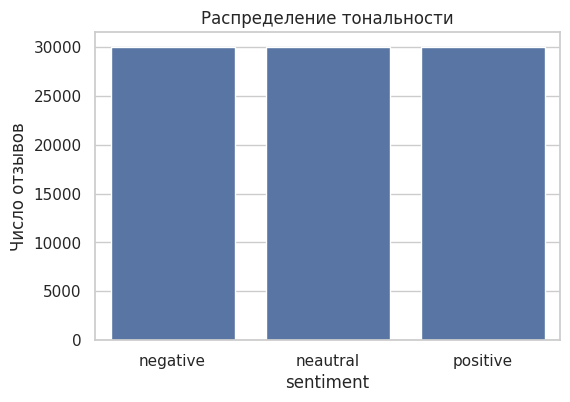

In [7]:
class_counts = df["sentiment"].value_counts()
print(class_counts)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax, color="#4C72B0")
ax.set_ylabel("Число отзывов")
ax.set_title("Распределение тональности")
plt.show()

### 3.2 Длина отзывов

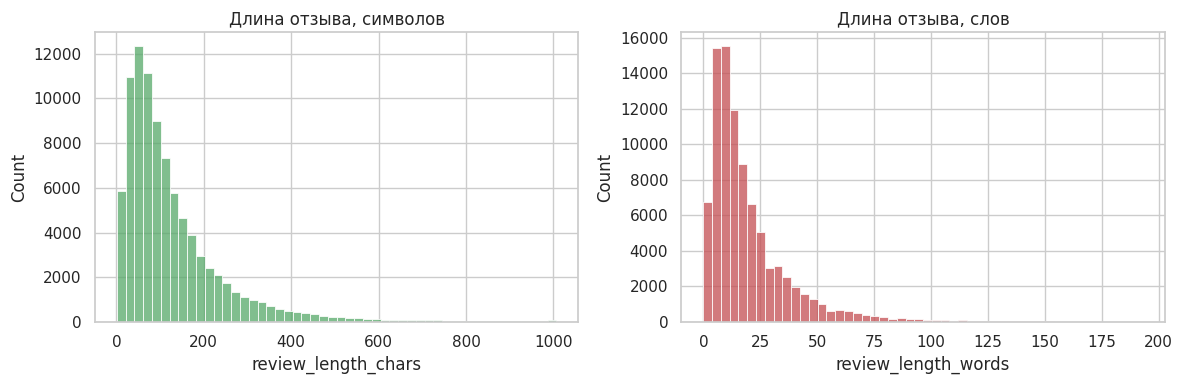

count    90000.000000
mean       130.069311
std        126.137185
min          1.000000
25%         51.000000
50%         91.000000
75%        164.000000
max       1007.000000
Name: review_length_chars, dtype: float64


In [8]:
df["review_length_chars"] = df["review"].str.len()
df["review_length_words"] = df["review"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["review_length_chars"], bins=50, ax=axes[0], color="#55A868")
axes[0].set_title("Длина отзыва, символов")
sns.histplot(df["review_length_words"], bins=50, ax=axes[1], color="#C44E52")
axes[1].set_title("Длина отзыва, слов")
plt.tight_layout()
plt.show()

print(df["review_length_chars"].describe())

### 3.3 Примеры отзывов по каждому классу

In [9]:
for sentiment in df["sentiment"].unique():
    print(f"--- {sentiment} ---")
    for review in df[df["sentiment"] == sentiment]["review"].sample(2, random_state=RANDOM_STATE):
        print(f"  {review[:200]}")
    print()

--- negative ---
  Размер совершенно не соответсвует действительности. Если вы 150см роста , то длина может и будет у вас как на картинке, я 172см и увы, пеньюар чуть ниже пупка, очень расстроена, зря деньги потратила 
  ждала заказ два с половиной месяца.  он так и не пришел. продавец продлевал время до тех пор, пока у меня было терпение. в итоге оно лопнуло.  открыла спор,  деньги вернули. очень огорчена (

--- neautral ---
  неаккуратный пошив, торчат нитки,
  на 54 заказала 3 хl. подошли, но немного отличаются по размеру. в черных комфортнее, талия повыше и штанины длиннее.

--- positive ---
  Пришло за 2.5 недели в Иркутскую область,заказала в подарок тети на вид красивый, нитки не много торчат.
  Заказ шёл месяц. заказала 5XL, на мой 52 очень впритык. А так все отлично: цвет, качество, нет запаха. Советую продавца. Буду заказывать ещё.



## 4. Train / val / test split

In [10]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["sentiment"])
CLASS_NAMES = label_encoder.classes_.tolist()
print("Классы:", CLASS_NAMES)

train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=RANDOM_STATE)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=RANDOM_STATE)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("train:", train_df.shape, "val:", val_df.shape, "test:", test_df.shape)

Классы: ['neautral', 'negative', 'positive']
train: (72000, 5) val: (9000, 5) test: (9000, 5)


## 5. Baseline — TF-IDF + логистическая регрессия

TF-IDF превращает текст в разреженный вектор частот слов (взвешенных по редкости) без понимания контекста, порядка слов или смысла


In [11]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(train_df["review"])
X_val_tfidf = tfidf.transform(val_df["review"])
X_test_tfidf = tfidf.transform(test_df["review"])

baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline.fit(X_train_tfidf, train_df["label"])

baseline_test_pred = baseline.predict(X_test_tfidf)
baseline_acc = accuracy_score(test_df["label"], baseline_test_pred)
baseline_f1 = f1_score(test_df["label"], baseline_test_pred, average="macro")

print(f"Baseline (TF-IDF + LogReg) — test accuracy: {baseline_acc:.4f} | macro F1: {baseline_f1:.4f}")

Baseline (TF-IDF + LogReg) — test accuracy: 0.7571 | macro F1: 0.7583


## 6. Токенизация и Dataset для BERT

In [12]:
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)


class ReviewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx], truncation=True, padding="max_length",
            max_length=self.max_length, return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
        }

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [13]:
train_dataset = ReviewsDataset(train_df["review"], train_df["label"], tokenizer, MAX_LENGTH)
val_dataset = ReviewsDataset(val_df["review"], val_df["label"], tokenizer, MAX_LENGTH)
test_dataset = ReviewsDataset(test_df["review"], test_df["label"], tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Батчей на эпоху (train):", len(train_loader))

Батчей на эпоху (train): 2250


## 7. Модель

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    CHECKPOINT, num_labels=len(CLASS_NAMES)
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Всего параметров: {n_params:,}")

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  714MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those par

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Всего параметров: 177,855,747


## 8. Функции train/eval

In [15]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="train", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * input_ids.size(0)
        all_preds.extend(outputs.logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, accuracy_score(all_labels, all_preds), f1_score(all_labels, all_preds, average="macro")


@torch.no_grad()
def evaluate(model, loader, device, return_preds=False):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="eval", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        total_loss += outputs.loss.item() * input_ids.size(0)
        all_preds.extend(outputs.logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    if return_preds:
        return avg_loss, acc, f1, np.array(all_labels), np.array(all_preds)
    return avg_loss, acc, f1


def plot_history(history):
    hist_df = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train", marker="o")
    axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="val", marker="o")
    axes[0].set_title(f"Loss (эпоха {hist_df['epoch'].iloc[-1]})")
    axes[0].set_xlabel("Эпоха")
    axes[0].legend()

    axes[1].plot(hist_df["epoch"], hist_df["train_f1"], label="train", marker="o", color="#4C72B0")
    axes[1].plot(hist_df["epoch"], hist_df["val_f1"], label="val", marker="o", color="#D85A30")
    axes[1].set_title(f"Macro F1 (эпоха {hist_df['epoch'].iloc[-1]})")
    axes[1].set_xlabel("Эпоха")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 9. Цикл обучения

train:   0%|          | 0/2250 [00:00<?, ?it/s]

eval:   0%|          | 0/282 [00:00<?, ?it/s]

Эпоха 1/6 (1661 сек) | train loss 0.5755 acc 0.7422 F1 0.7444 | val loss 0.5358 acc 0.7568 F1 0.7596


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> новый лучший чекпоинт (val F1 = 0.7596)


...

eval:   0%|          | 0/282 [00:00<?, ?it/s]

Эпоха 3/6 (1662 сек) | train loss 0.3995 acc 0.8287 F1 0.8300 | val loss 0.5686 acc 0.7619 F1 0.7613


train:   0%|          | 0/2250 [00:00<?, ?it/s]

eval:   0%|          | 0/282 [00:00<?, ?it/s]

Эпоха 4/6 (1660 сек) | train loss 0.3053 acc 0.8736 F1 0.8744 | val loss 0.6306 acc 0.7580 F1 0.7570
  -> нет улучшений 2 эпох подряд, останавливаемся раньше


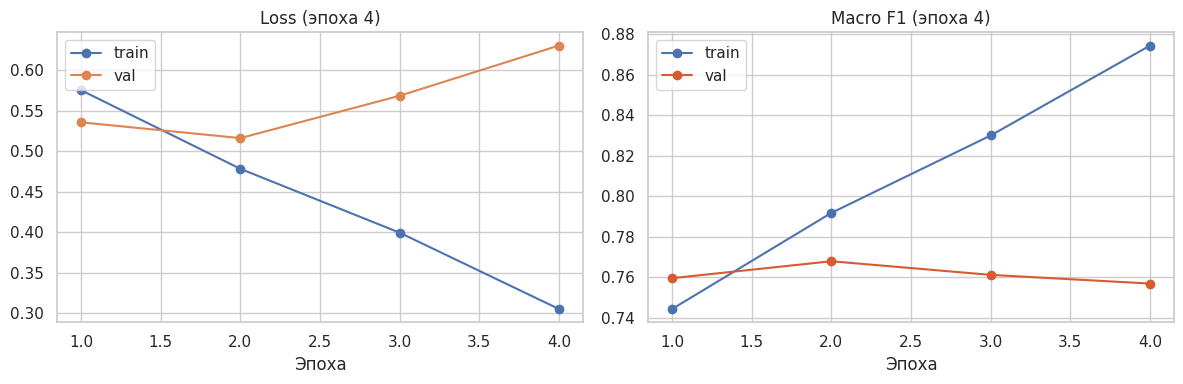

In [16]:
history = []
best_val_f1 = -1
epochs_without_improvement = 0
CHECKPOINT_PATH = "/content/rubert_sentiment_best"

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, DEVICE)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, DEVICE)
    scheduler.step()

    elapsed = time.time() - start_time
    history.append({
        "epoch": epoch, "train_loss": train_loss, "train_acc": train_acc, "train_f1": train_f1,
        "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1, "seconds": elapsed,
    })

    print(f"Эпоха {epoch}/{EPOCHS} ({elapsed:.0f} сек) | "
          f"train loss {train_loss:.4f} acc {train_acc:.4f} F1 {train_f1:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f} F1 {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_without_improvement = 0
        model.save_pretrained(CHECKPOINT_PATH)
        tokenizer.save_pretrained(CHECKPOINT_PATH)
        print(f"  -> новый лучший чекпоинт (val F1 = {val_f1:.4f})")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"  -> нет улучшений {EARLY_STOP_PATIENCE} эпох подряд, останавливаемся раньше")
            break

plot_history(history)
pd.DataFrame(history).to_csv("/content/bert_history.csv", index=False)

## 10. Загрузка лучшего чекпоинта, оценка на тесте

In [17]:
best_model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT_PATH).to(DEVICE)

test_loss, test_acc, test_f1, y_true, y_pred = evaluate(best_model, test_loader, DEVICE, return_preds=True)
print(f"BERT — test accuracy: {test_acc:.4f} | macro F1: {test_f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

eval:   0%|          | 0/282 [00:00<?, ?it/s]

BERT — test accuracy: 0.7700 | macro F1: 0.7741

              precision    recall  f1-score   support

    neautral       0.62      0.83      0.71      3000
    negative       0.83      0.65      0.73      3000
    positive       0.94      0.83      0.88      3000

    accuracy                           0.77      9000
   macro avg       0.80      0.77      0.77      9000
weighted avg       0.80      0.77      0.77      9000



## 11. Confusion matrix

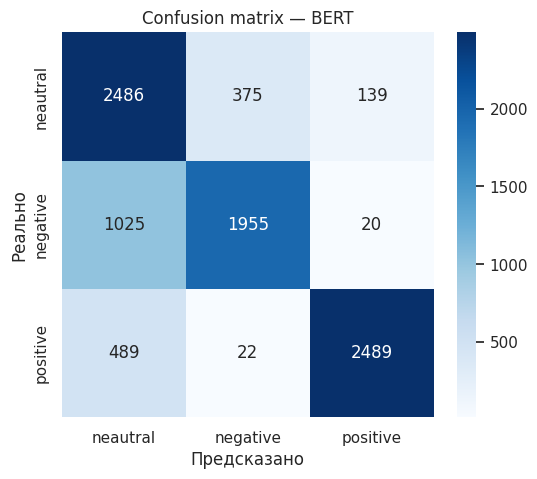

In [18]:
cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASS_NAMES)))
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel("Предсказано")
ax.set_ylabel("Реально")
ax.set_title("Confusion matrix — BERT")
plt.show()

## 12. Baseline vs BERT, итоговое сравнение

In [19]:
comparison = pd.DataFrame([
    {"model": "TF-IDF + LogReg (baseline)", "test_accuracy": baseline_acc, "test_macro_F1": baseline_f1},
    {"model": "BERT (fine-tuned)", "test_accuracy": test_acc, "test_macro_F1": test_f1},
]).sort_values("test_macro_F1", ascending=False)

comparison

,model,test_accuracy,test_macro_F1
1,BERT (fine-tuned),0.770000,0.774076
0,TF-IDF + LogReg (baseline),0.757111,0.758299


BERT обошёл baseline, но разрыв небольшой и это можно объяснить тем, что отзывы на маркетплейсе это короткие тексты, где тональность часто
выражена явными словами, а именно такие сигналы TF-IDF, считающий частоты слов и биграмм без всякого
понимания контекста, ловит почти очень хорошо

Контекстное преимущество sa должно проявляться сильнее
на текстах с отрицанием ("не могу сказать, что это плохо"), сарказмом или
же неоднозначной тональностью внутри одного отзыва, потому что именно там
порядок слов и контекст важны

для этой относительно "простой" по языку задачи разница в подходах дает небольшой прирост

## 13. Анализ ошибок

In [20]:
error_analysis = test_df.copy().reset_index(drop=True)
error_analysis["true_label"] = [CLASS_NAMES[i] for i in y_true]
error_analysis["pred_label"] = [CLASS_NAMES[i] for i in y_pred]
error_analysis["correct"] = error_analysis["true_label"] == error_analysis["pred_label"]

errors = error_analysis[~error_analysis["correct"]]
print(f"Всего ошибок на test: {len(errors)} из {len(error_analysis)} ({len(errors)/len(error_analysis)*100:.1f}%)")

print("\nПутаница по парам классов (реальный -> предсказанный), топ-6:")
print(errors.groupby(["true_label", "pred_label"]).size().sort_values(ascending=False).head(6))

Всего ошибок на test: 2070 из 9000 (23.0%)

Путаница по парам классов (реальный -> предсказанный), топ-6:
true_label  pred_label
negative    neautral      1025
positive    neautral       489
neautral    negative       375
            positive       139
positive    negative        22
negative    positive        20
dtype: int64


In [21]:
print("Несколько примеров ошибок:\n")
for _, row in errors.sample(5, random_state=RANDOM_STATE).iterrows():
    print(f"Реально: {row['true_label']} | Предсказано: {row['pred_label']}")
    print(f"Текст: {row['review'][:250]}")
    print()

Несколько примеров ошибок:

Реально: negative | Предсказано: neautral
Текст: до этого заказывал в этом магазине точно такие же джинсы только красного цвета. размер у красных 25. решили купить такие же черные, пришли джинсы в талии на пару сантиметров шире, по длине также даже больше. в итоге вещь не подошла. как можно шить од

Реально: negative | Предсказано: neautral
Текст: прислали другой цвет. Я закпзывала Green а это темно коричневый

Реально: neautral | Предсказано: negative
Текст: Товар не соответствует фото. Качество ужасное.

Реально: neautral | Предсказано: negative
Текст: Быстрая доставка, но курткой разочарованы. Очень слабые кнопки и рукава короткие. Не рекомендую, этих денег куртка не стоит.

Реально: positive | Предсказано: neautral
Текст: Доставка долгая, а так все хорошо



Минимум два случая размечены как neautral, хотя текст негативный и BERT
предсказал negative. 
это прямое подтверждение того, что часть ошибок это шум в автоматической разметке, а остальные случаи  выглядят как пограничные сложности задачи, поэтому там уже вероятнее
реальная ошибка модели или объективная двусмысленность отзыва

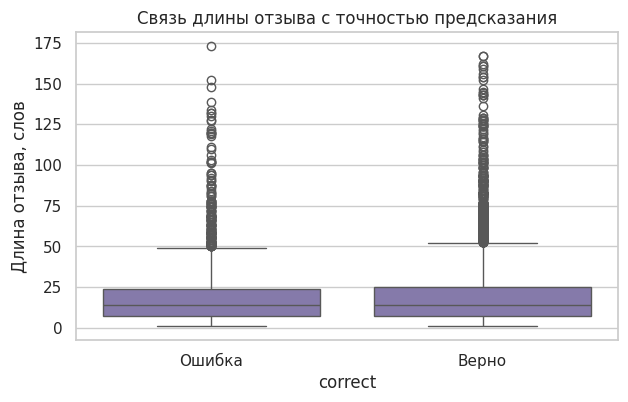

In [22]:
error_analysis["review_length_words"] = error_analysis["review"].str.split().str.len()

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=error_analysis, x="correct", y="review_length_words", ax=ax, color="#8172B2")
ax.set_xticklabels(["Ошибка", "Верно"])
ax.set_ylabel("Длина отзыва, слов")
ax.set_title("Связь длины отзыва с точностью предсказания")
plt.show()

## 14. Выводы

**Baseline vs BERT** 

TF-IDF+LogReg — accuracy 0.7571, macro F1 0.7583.
BERT — accuracy 0.7700, macro F1 0.7741. Прирост небольшой (+1.3 п.п.
accuracy, +1.6 п.п. macro F1) — контекстные представления self-attention
не дают кардинальное преимущество над bag of words на этой
конкретной задаче (короткие, лексически прямые отзывы на маркетплейсе, где
тональность часто выражена явными словами, которые TF-IDF ловит хорошо)


**Анализ ошибок** 

Доля ошибок на test — 23.0% (2070 из 9000). Среди
прочитанных вручную примеров (раздел 13) — 2 из 5 выглядят как реальный шум
в автоматической разметке (текст явно негативный, но размечен как
neautral, а BERT предсказал negative), 3 из 5 — как
честные, пограничные сложности самой задачи (негативный факт, изложенный
нейтральным тоном; смешанная тональность внутри одного отзыва). Маленькая
выборка, не строгая статистика, но направление честное

**Длина отзыва и точность** 

Заметной связи не обнаружено — распределение
длины (в словах) практически идентично и для верных, и для ошибочных
предсказаний (медиана и межквартильный размах совпадают на графике)

**Ограничение** 

Метрики безкросс-валидации, метки получены автоматически из оценок товара, не через
ручную разметку тональности текста, причем верхняя граница качества ограничена
шумностью самой разметки

**Что можно улучшить дальше** 

Отдельная стратегия для границы
negative/neautral; можно попробовать asymmetric class weights или отдельный
бинарный классификатор "явный негатив vs остальное" как первый фильтр.
Ручная перепроверка большей выборки (не 5, а 50-100) "ошибок" для более
строгой оценки доли шума в разметке против настоящих промахов модели;
`rubert-tiny2` для сравнения скорости/качества с более компактной моделью